# BEAD RF — SHAP, Ablation, and Feature Importance Analysis
Loads the pre-saved enriched dataset, trains the final integrated model, and produces:
1. Feature ablation table
2. Normalized feature importance table (RF Gini, SHAP, LIME)
3. SHAP beeswarm summary plot

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

from google.cloud import bigquery

warnings.filterwarnings('ignore')

client = bigquery.Client(project='broadband-data')
print('Connected to BigQuery: broadband-data')

import shutil
HAS_LATEX = shutil.which('pdflatex') is not None

plt.rcParams.update({
    'text.usetex': HAS_LATEX,       # True when pdflatex available, renders Computer Modern
    'font.family': 'serif',
    'font.serif': ['Computer Modern Roman'],
    'font.size': 9,
    'mathtext.fontset': 'cm',
    'figure.dpi': 300,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
})

if not HAS_LATEX:
    print('Note: pdflatex not found — using mathtext fallback. '
          'Install TeX Live for full LaTeX rendering.')

Connected to BigQuery: broadband-data


In [2]:
# ── Load pre-saved enriched dataset ─────────────────────────────────────────
df_raw = pd.read_parquet('bead_fp_enriched.parquet')
df_raw = df_raw.sort_values(by='project_id', ascending=True).reset_index(drop=True)

low  = df_raw['funding_per_location'].quantile(0.025)
high = df_raw['funding_per_location'].quantile(0.975)
df = df_raw[(df_raw['funding_per_location'] >= low) & (df_raw['funding_per_location'] <= high)].copy()
df = df.reset_index(drop=True)

print(f'Trimmed dataset: {df.shape[0]} projects')

Trimmed dataset: 5453 projects


In [3]:
# ── Feature set (19 features) ────────────────────────────────────────────────
# Dropped: frac_fiber_comp, frac_cable_comp, frac_fw_comp (redundant with tech fracs)
FEATURE_COLS = [
    # Technology mix
    'frac_tech_40',
    'frac_tech_50',
    'frac_tech_61',
    'frac_tech_71',
    # Project-level
    'miles_per_location',
    'pct_aerial',
    'pct_cai',
    'n_total',
    # Competition (Dec 2024 NBM)
    'frac_competitor_qualifying',
    'frac_wired_qualifying',
    # ISP incumbency / coverage
    'prov_coverage',
    'frac_present_at_location',
    'nearest_mi_served_same_isp',
    'nearest_mi_served_any',
    'no_prior_presence_frac',
    # Geography — county-level weighted means
    'POPDEN_RUR_wmean',
    'POPDEN_COU_wmean',
    'rucc_code_wmean',
    'poverty_rate_wmean',
]

pretty_names_map = {
    'frac_tech_40':               'frac_tech_40 (HFC)',
    'frac_tech_50':               'frac_tech_50 (Fiber)',
    'frac_tech_61':               'frac_tech_61 (LEO)',
    'frac_tech_71':               'frac_tech_71 (FW)',
    'miles_per_location':         'miles_per_loc',
    'pct_aerial':                 'pct_aerial',
    'pct_cai':                    'pct_cai',
    'n_total':                    'n_total',
    'frac_competitor_qualifying': 'frac_q_comp',
    'frac_wired_qualifying':      'frac_q_wired',
    'prov_coverage':              'isp_coverage',
    'frac_present_at_location':   'frac_presence',
    'nearest_mi_served_same_isp': 'nearest_own_mi',
    'nearest_mi_served_any':      'nearest_any_mi',
    'no_prior_presence_frac':     'no_prior_presence',
    'POPDEN_RUR_wmean':           'rur_popden',
    'POPDEN_COU_wmean':           'cou_popden',
    'rucc_code_wmean':            'rucc_code',
    'poverty_rate_wmean':         'poverty_rate',
}

X = df[FEATURE_COLS].fillna(0)
y = df['log_funding']


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

rf = RandomForestRegressor(n_estimators=1000, min_samples_split=2, min_samples_leaf=1,
                            max_features=0.3, max_depth=20, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

baseline_r2   = r2_score(y_test, y_pred)
baseline_rmse = np.sqrt(mean_squared_error(np.expm1(y_test), np.expm1(y_pred)))
baseline_mae  = mean_absolute_error(np.expm1(y_test), np.expm1(y_pred))

kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_r2 = cross_val_score(rf, X, y, cv=kf, scoring='r2')

print(f'Dataset size: {X.shape[0]}')
print(f'Features: {len(FEATURE_COLS)}')
print(f'Test R²  (log): {baseline_r2:.4f}')
print(f'CV R²   (log): {cv_r2.mean():.4f} ± {cv_r2.std():.4f}')
print(f'RMSE (real $): ${baseline_rmse:,.0f}')
print(f'MAE  (real $): ${baseline_mae:,.0f}')

Dataset size: 5453
Features: 19
Test R²  (log): 0.7116
CV R²   (log): 0.7220 ± 0.0149
RMSE (real $): $3,288
MAE  (real $): $1,782


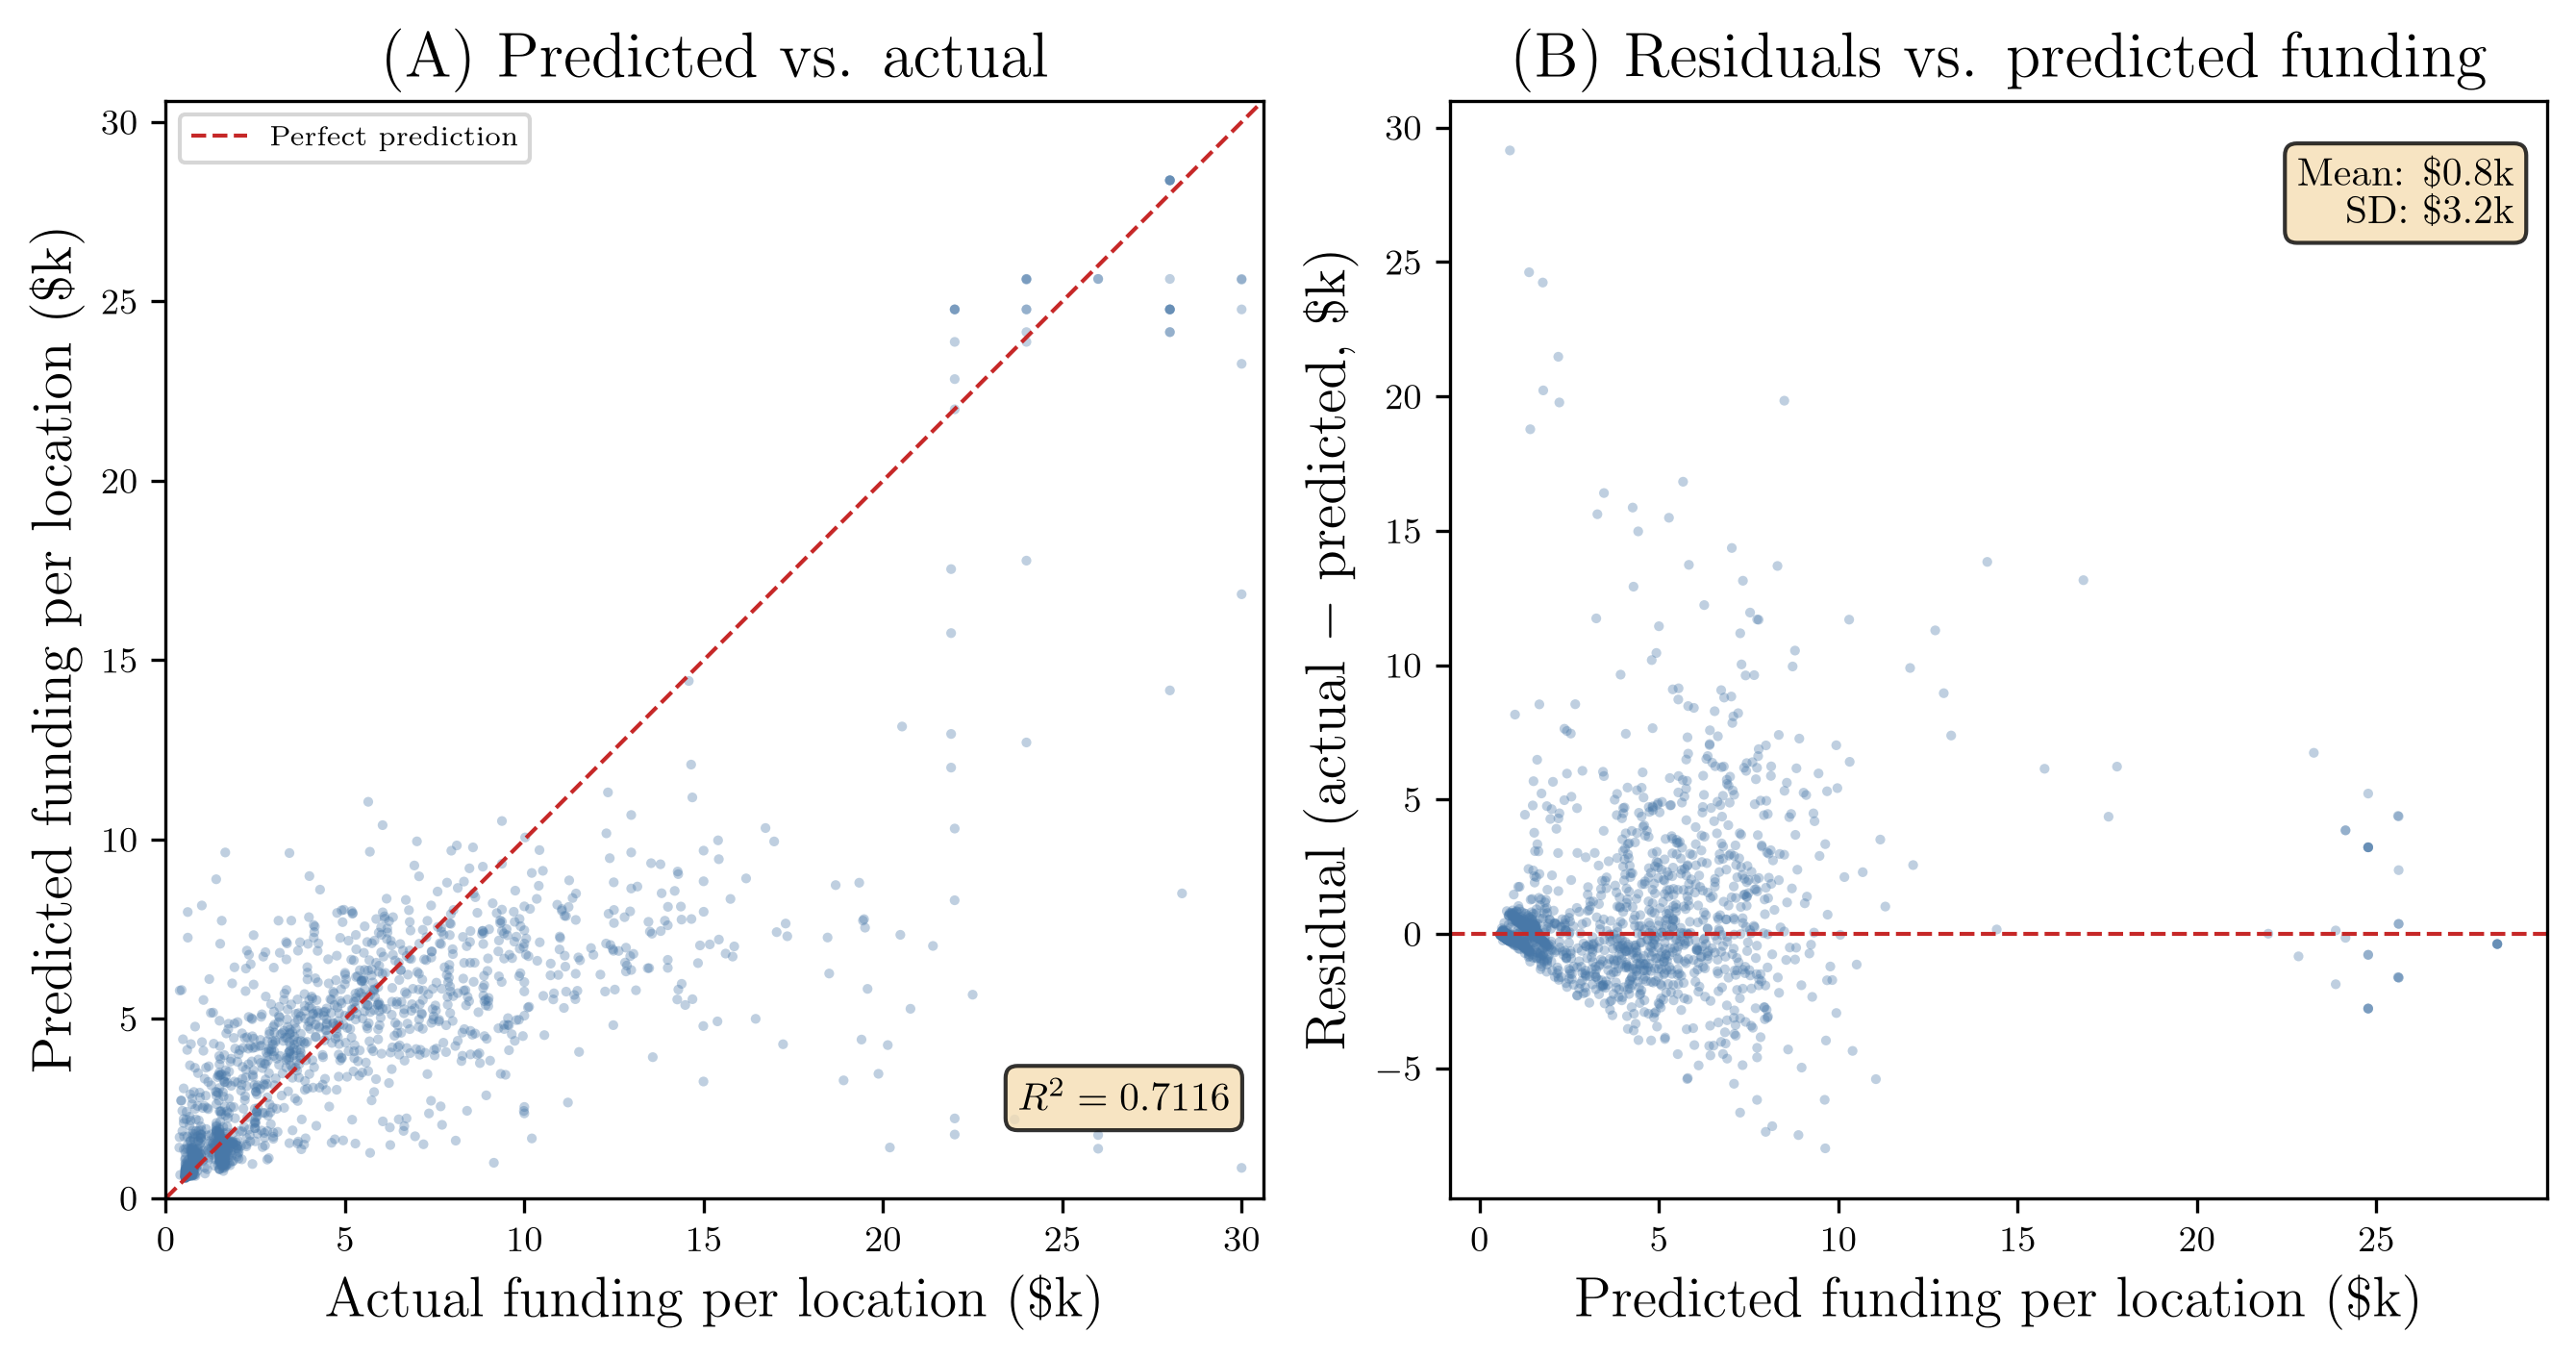

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(9, 4.5))
actual = np.expm1(y_test)
predicted = np.expm1(y_pred)
residuals_dollar = actual - predicted

ax[0].scatter(actual / 1000, predicted / 1000,
           s=6, alpha=0.35, color='#4878A8', edgecolors='none', rasterized=True)

lims = [0, max(actual.max(), predicted.max()) / 1000 * 1.02]
ax[0].plot(lims, lims, '--', color='#C62828', lw=1.0, label='Perfect prediction')
ax[0].set_xlabel('Actual funding per location (\\$k)' if HAS_LATEX else 'Actual funding per location ($k)', fontsize=14)
ax[0].set_ylabel('Predicted funding per location (\\$k)' if HAS_LATEX else 'Predicted funding per location ($k)', fontsize=14)
ax[0].set_title('(A) Predicted vs. actual', weight='bold', fontsize=16)
ax[0].legend(fontsize=7, loc='upper left')
ax[0].set_xlim(lims)
ax[0].set_ylim(lims)
ax[0].set_box_aspect(1)

r2_label = f'$R^2 = {baseline_r2:.4f}$' if HAS_LATEX else f'R² = {baseline_r2:.4f}'
ax[0].text(0.97, 0.08, r2_label,
        transform=ax[0].transAxes, ha='right', fontsize=10,
        bbox=dict(boxstyle='round,pad=0.3', facecolor='wheat', alpha=0.8))

ax[1].scatter(predicted / 1000, residuals_dollar / 1000,
           s=6, alpha=0.35, color='#4878A8', edgecolors='none', rasterized=True)
ax[1].axhline(0, color='#C62828', lw=1.0, linestyle='--')
ax[1].set_xlabel('Predicted funding per location (\\$k)', fontsize=14)
ax[1].set_ylabel('Residual (actual $-$ predicted, \\$k)', fontsize=14)
ax[1].set_title('(B) Residuals vs. predicted funding', weight='bold', fontsize=16)
ax[1].set_box_aspect(1)

mean_res = residuals_dollar.mean()
std_res = residuals_dollar.std()
ax[1].text(0.97, 0.95,
        f'Mean: \\${mean_res/1000:.1f}k\nSD: \\${std_res/1000:.1f}k',
        transform=ax[1].transAxes, ha='right', va='top', fontsize=10,
        bbox=dict(boxstyle='round,pad=0.3', facecolor='wheat', alpha=0.8))

plt.tight_layout()
plt.show()

## 1. Feature Ablation

In [5]:
ablation_results = []

for feat in FEATURE_COLS:
    cols_reduced = [c for c in FEATURE_COLS if c != feat]
    X_tr = X_train[cols_reduced]
    X_te = X_test[cols_reduced]

    rf_ab = RandomForestRegressor(
        n_estimators=200, min_samples_split=2, min_samples_leaf=1,
        max_features=0.3, max_depth=20, random_state=42, n_jobs=-1
    )
    rf_ab.fit(X_tr, y_train)
    yp = rf_ab.predict(X_te)

    r2   = r2_score(y_test, yp)
    rmse = np.sqrt(mean_squared_error(np.expm1(y_test), np.expm1(yp)))
    mae  = mean_absolute_error(np.expm1(y_test), np.expm1(yp))

    ablation_results.append({
        'feature': feat,
        'r2':      r2,
        'delta_r2': r2 - baseline_r2,
        'rmse':    rmse,
        'mae':     mae,
    })
    print(f'  {feat:35s}  R²={r2:.4f}  ΔR²={r2-baseline_r2:+.4f}  RMSE=${rmse:,.0f}')

abl_df = pd.DataFrame(ablation_results).sort_values('delta_r2')
print(f'\nBaseline Test R² = {baseline_r2:.4f}')

  frac_tech_40                         R²=0.7073  ΔR²=-0.0042  RMSE=$3,305
  frac_tech_50                         R²=0.7124  ΔR²=+0.0008  RMSE=$3,300
  frac_tech_61                         R²=0.7068  ΔR²=-0.0048  RMSE=$3,312
  frac_tech_71                         R²=0.7116  ΔR²=+0.0000  RMSE=$3,291
  miles_per_location                   R²=0.6705  ΔR²=-0.0411  RMSE=$3,424
  pct_aerial                           R²=0.7102  ΔR²=-0.0014  RMSE=$3,305
  pct_cai                              R²=0.7123  ΔR²=+0.0007  RMSE=$3,297
  n_total                              R²=0.6989  ΔR²=-0.0127  RMSE=$3,371
  frac_competitor_qualifying           R²=0.7125  ΔR²=+0.0009  RMSE=$3,261
  frac_wired_qualifying                R²=0.7146  ΔR²=+0.0030  RMSE=$3,279
  prov_coverage                        R²=0.7112  ΔR²=-0.0004  RMSE=$3,282
  frac_present_at_location             R²=0.7108  ΔR²=-0.0008  RMSE=$3,284
  nearest_mi_served_same_isp           R²=0.7099  ΔR²=-0.0016  RMSE=$3,288
  nearest_mi_served_any  

In [6]:
# ── LaTeX: Ablation table ────────────────────────────────────────────────────
print(r"""\begin{table*}[ht]
\centering""")
print(f"""\\caption{{Feature ablation results. Baseline Test $R^2 = {baseline_r2:.4f}$.}}
\\label{{tab:ablation}}
\\begin{{tabularx}}{{\\textwidth}}{{>{{\\ttfamily}}Xcccc}}
\\toprule
\\textbf{{Feature}} & \\textbf{{Test $R^2$}} & \\textbf{{$\\Delta R^2$}} & \\textbf{{RMSE (\\$)}} & \\textbf{{MAE (\\$)}} \\\\
\\midrule""")

neg_rows = abl_df[abl_df['delta_r2'] <= 0].sort_values('delta_r2')
pos_rows = abl_df[abl_df['delta_r2'] > 0].sort_values('delta_r2', ascending=False)

for _, row in neg_rows.iterrows():
    feat = row['feature'].replace('_', '\\_')
    sign = '+' if row['delta_r2'] >= 0 else '-'
    print(f"{feat:45s} & {row['r2']:.4f} & ${row['delta_r2']:+.4f}$ & "
          f"{row['rmse']:,.0f} & {row['mae']:,.0f} \\\\")

if not pos_rows.empty:
    print(r"\hhline{=====}")
    for _, row in pos_rows.iterrows():
        feat = row['feature'].replace('_', '\\_')
        print(f"{feat:45s} & {row['r2']:.4f} & ${row['delta_r2']:+.4f}$ & "
              f"{row['rmse']:,.0f} & {row['mae']:,.0f} \\\\")

print(r"""\bottomrule
\end{tabularx}
\end{table*}""")

\begin{table*}[ht]
\centering
\caption{Feature ablation results. Baseline Test $R^2 = 0.7116$.}
\label{tab:ablation}
\begin{tabularx}{\textwidth}{>{\ttfamily}Xcccc}
\toprule
\textbf{Feature} & \textbf{Test $R^2$} & \textbf{$\Delta R^2$} & \textbf{RMSE (\$)} & \textbf{MAE (\$)} \\
\midrule
miles\_per\_location                          & 0.6705 & $-0.0411$ & 3,424 & 1,927 \\
POPDEN\_RUR\_wmean                            & 0.6820 & $-0.0296$ & 3,443 & 1,877 \\
n\_total                                      & 0.6989 & $-0.0127$ & 3,371 & 1,807 \\
POPDEN\_COU\_wmean                            & 0.7040 & $-0.0076$ & 3,347 & 1,811 \\
frac\_tech\_61                                & 0.7068 & $-0.0048$ & 3,312 & 1,795 \\
rucc\_code\_wmean                             & 0.7072 & $-0.0043$ & 3,293 & 1,794 \\
frac\_tech\_40                                & 0.7073 & $-0.0042$ & 3,305 & 1,797 \\
no\_prior\_presence\_frac                     & 0.7093 & $-0.0022$ & 3,289 & 1,783 \\
poverty\_rate\_wmean  

## 2. SHAP Analysis

In [7]:
try:
    import shap
except ImportError:
    import subprocess
    subprocess.check_call(['pip', 'install', 'shap', '-q'])
    import shap

print(f'SHAP version: {shap.__version__}')

explainer   = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_test)
print(f'SHAP values shape: {shap_values.shape}')

SHAP version: 0.51.0
SHAP values shape: (1636, 19)


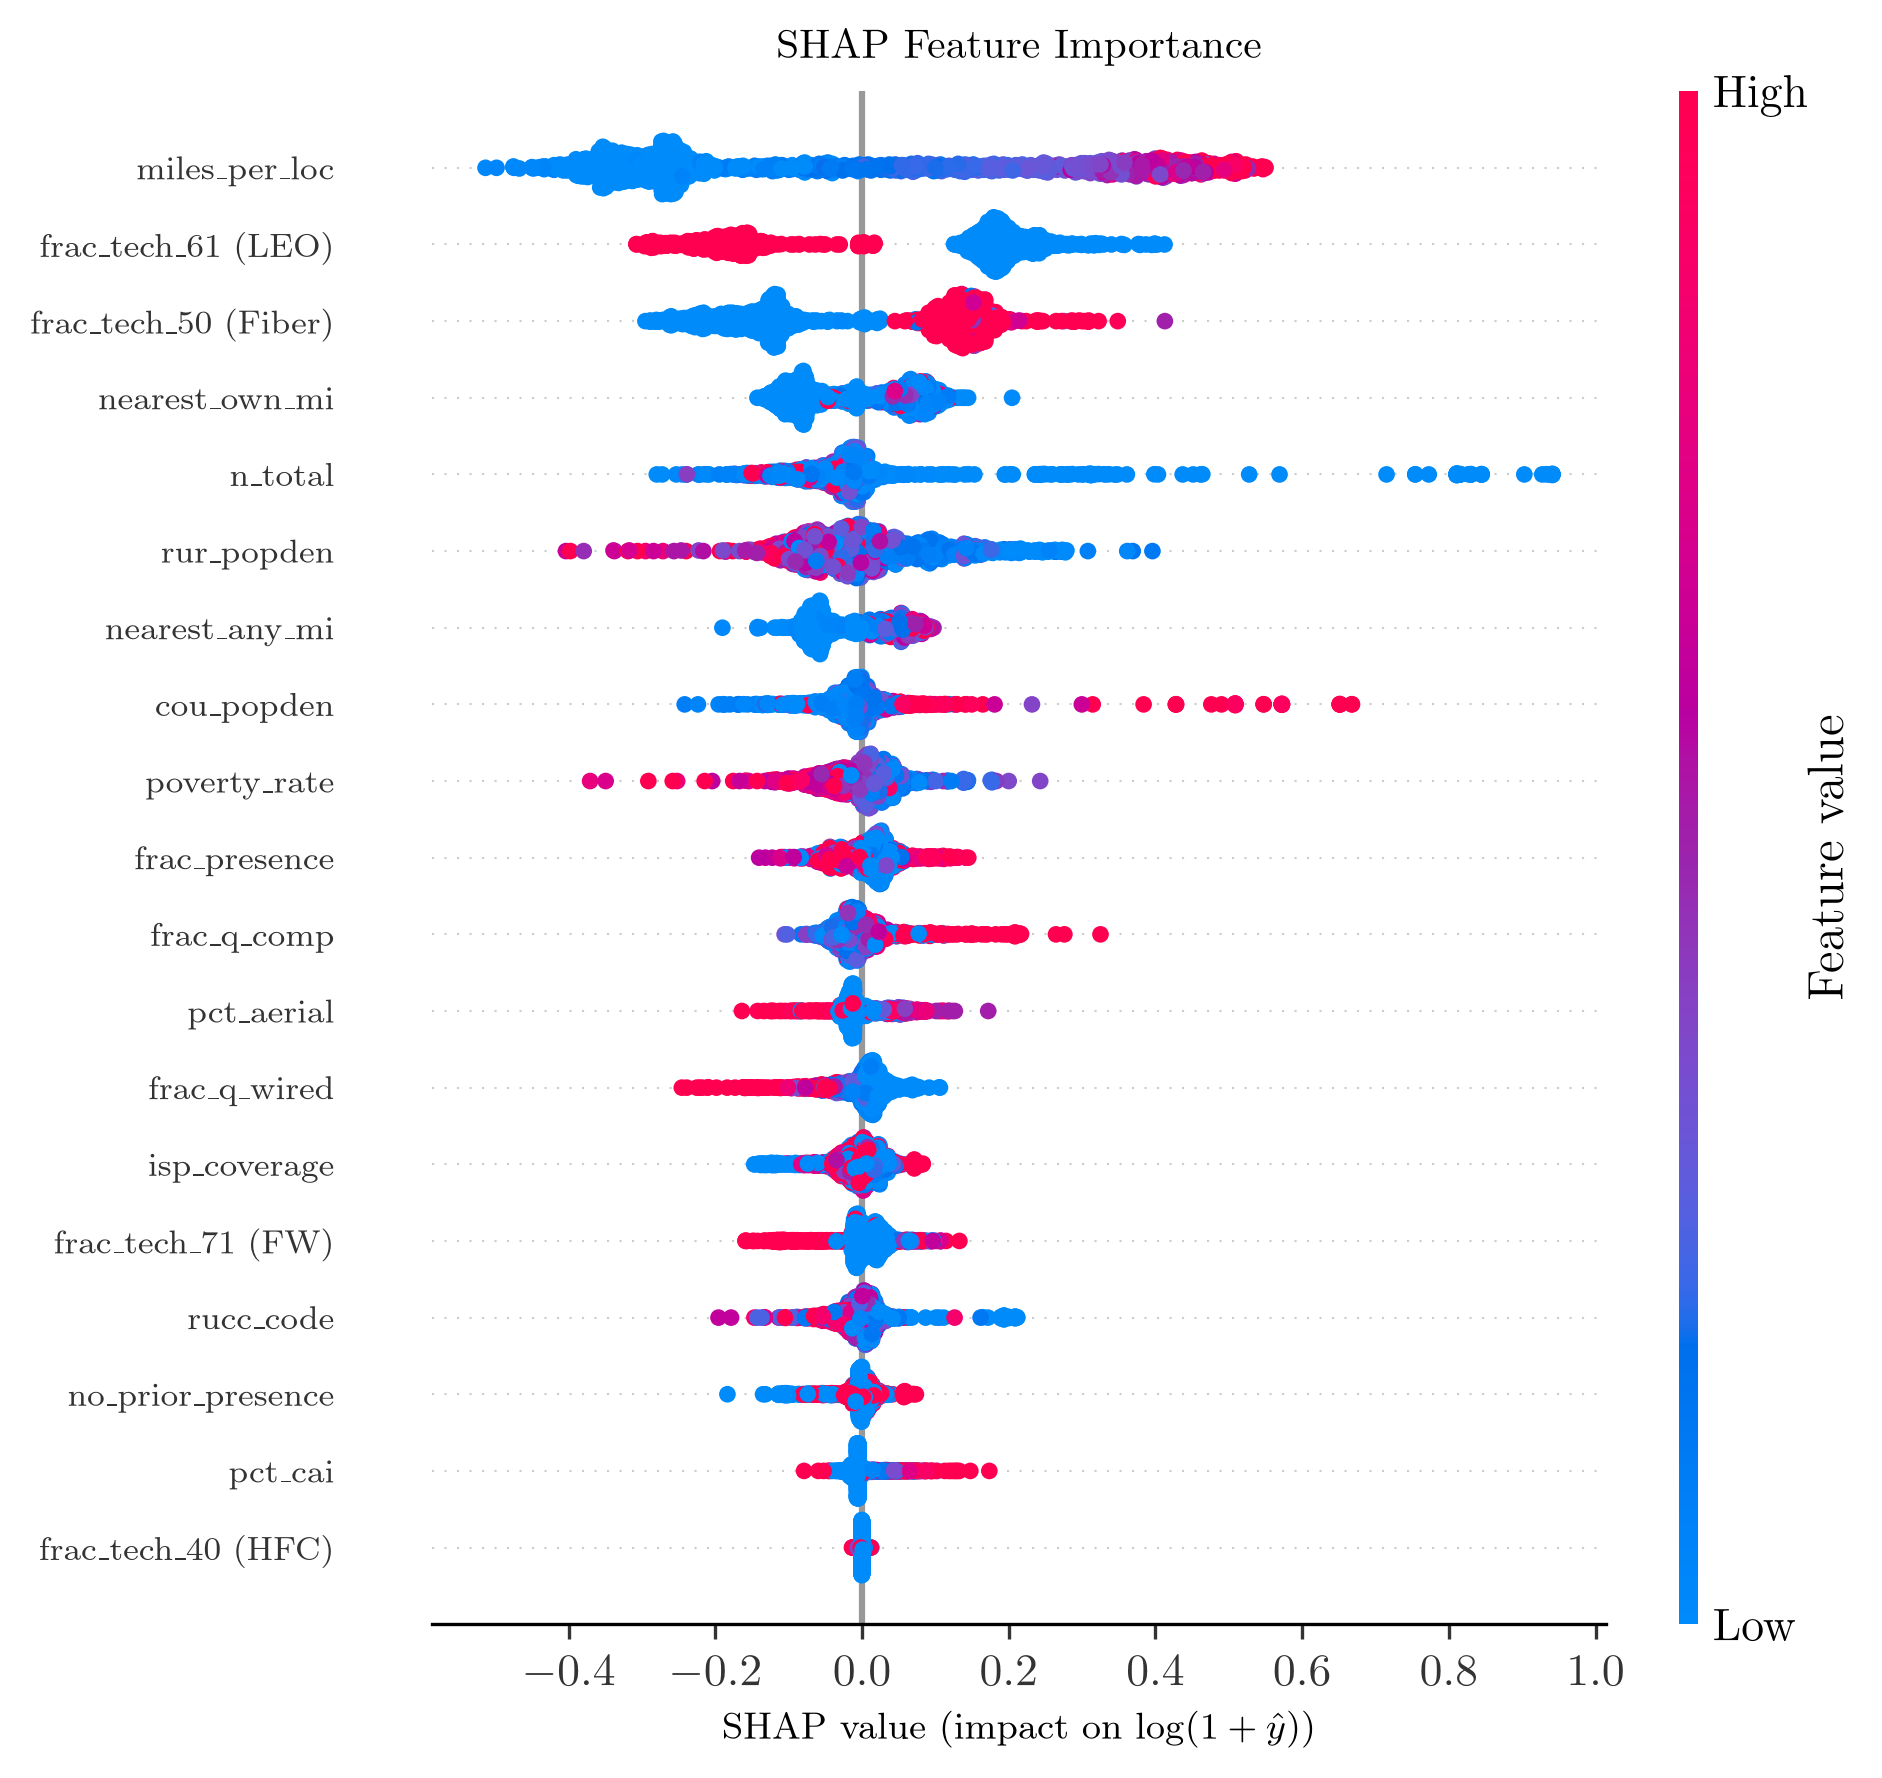

LaTeX rendered: True
Saved: fig_shap_beeswarm.pdf / fig_shap_beeswarm.png


In [8]:

import shutil

HAS_LATEX = shutil.which('pdflatex') is not None
plt.rcParams.update({
    'text.usetex':       HAS_LATEX,
    'font.family':       'serif',
    'font.serif':        ['Computer Modern Roman'],
    'font.size':         9,
    'mathtext.fontset':  'cm',
    'figure.dpi':        300,
    'savefig.dpi':       300,
    'savefig.bbox':      'tight',
})

plot_names = [pretty_names_map[c] for c in FEATURE_COLS]

# SHAP summary_plot draws into current figure — set size first
plt.figure(figsize=(6.5, 6.0))
shap.summary_plot(
    shap_values, X_test,
    feature_names=plot_names,
    show=False,
    plot_size=None,
    color_bar_label='Feature value',
)

ax = plt.gca()
ax.set_xlabel(
    r'SHAP value (impact on $\log(1 + \hat{y})$)' if HAS_LATEX
    else 'SHAP value (impact on log(1 + ŷ))',
    fontsize=9
)
ax.set_title('SHAP Feature Importance', weight='bold', fontsize=10, pad=8)
ax.tick_params(axis='y', labelsize=8)

plt.tight_layout()
plt.savefig('fig_shap_beeswarm.pdf')
plt.savefig('fig_shap_beeswarm.png')
plt.show()
print(f'LaTeX rendered: {HAS_LATEX}')
print('Saved: fig_shap_beeswarm.pdf / fig_shap_beeswarm.png')


## 3. Normalized Importance Table (RF Gini + SHAP)

In [9]:

# ── Collect and normalize ────────────────────────────────────────────────────
gini_raw = rf.feature_importances_
shap_raw = np.abs(shap_values).mean(axis=0)

def norm(arr):
    s = arr.sum()
    return arr / s if s > 0 else arr

importance_df = pd.DataFrame({
    'feature': FEATURE_COLS,
    'pretty':  [pretty_names_map[c] for c in FEATURE_COLS],
    'gini':    norm(gini_raw),
    'shap':    norm(shap_raw),
}).sort_values('shap', ascending=False)

print(importance_df[['pretty','gini','shap']].to_string(index=False))


              pretty     gini     shap
       miles_per_loc 0.201245 0.247771
  frac_tech_61 (LEO) 0.078400 0.164851
frac_tech_50 (Fiber) 0.099902 0.126637
      nearest_own_mi 0.056461 0.063275
             n_total 0.086477 0.057987
          rur_popden 0.073572 0.057924
      nearest_any_mi 0.043215 0.044520
          cou_popden 0.076602 0.031966
        poverty_rate 0.047165 0.030404
       frac_presence 0.027956 0.025789
         frac_q_comp 0.037005 0.022646
          pct_aerial 0.026794 0.022009
        frac_q_wired 0.025077 0.021634
        isp_coverage 0.036894 0.019805
   frac_tech_71 (FW) 0.020400 0.018942
           rucc_code 0.035570 0.018863
   no_prior_presence 0.013409 0.012385
             pct_cai 0.012494 0.012077
  frac_tech_40 (HFC) 0.001362 0.000516


In [10]:
# ── LaTeX: Normalized importance table (Gini + SHAP) ────────────────────────
print(r"""\begin{table}[h]
  \centering
  \caption{Normalized feature importance from RF Gini and SHAP}
  \label{tab:importance_comparison}
  \begin{tabular}{lcc}
  \hline
  \textbf{Feature} & \textbf{RF Gini} & \textbf{SHAP} \\\\
  \hline""")

for _, row in importance_df.iterrows():
    feat = '\\texttt{' + row['pretty'].replace('_', '\\_') + '}'
    print(f"  {feat:50s} & {row['gini']:.3f} & {row['shap']:.3f} \\\\")

print(r"""  \hline
  \end{tabular}
\end{table}""")


\begin{table}[h]
  \centering
  \caption{Normalized feature importance from RF Gini and SHAP}
  \label{tab:importance_comparison}
  \begin{tabular}{lcc}
  \hline
  \textbf{Feature} & \textbf{RF Gini} & \textbf{SHAP} \\\\
  \hline
  \texttt{miles\_per\_loc}                           & 0.201 & 0.248 \\
  \texttt{frac\_tech\_61 (LEO)}                      & 0.078 & 0.165 \\
  \texttt{frac\_tech\_50 (Fiber)}                    & 0.100 & 0.127 \\
  \texttt{nearest\_own\_mi}                          & 0.056 & 0.063 \\
  \texttt{n\_total}                                  & 0.086 & 0.058 \\
  \texttt{rur\_popden}                               & 0.074 & 0.058 \\
  \texttt{nearest\_any\_mi}                          & 0.043 & 0.045 \\
  \texttt{cou\_popden}                               & 0.077 & 0.032 \\
  \texttt{poverty\_rate}                             & 0.047 & 0.030 \\
  \texttt{frac\_presence}                            & 0.028 & 0.026 \\
  \texttt{frac\_q\_comp}                          

In [11]:
# ── Save importance data to CSV ──────────────────────────────────────────────
importance_df.to_csv('feature_importances.csv', index=False)
abl_df.to_csv('ablation_results.csv', index=False)
print('Saved feature_importances.csv and ablation_results.csv')

Saved feature_importances.csv and ablation_results.csv


## 4. Model Comparison Table

In [12]:

from sklearn.linear_model import Ridge, Lasso, LinearRegression
from sklearn.model_selection import cross_val_score, KFold
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
import warnings; warnings.filterwarnings('ignore')

kf5 = KFold(n_splits=5, shuffle=True, random_state=42)

def evaluate(model, X_tr, X_te, y_tr, y_te, dollar=True):
    model.fit(X_tr, y_tr)
    yp  = model.predict(X_te)
    r2  = r2_score(y_te, yp)
    cv  = cross_val_score(model, np.vstack([X_tr, X_te]),
                          np.concatenate([y_tr, y_te]),
                          cv=kf5, scoring='r2')
    if dollar:
        rmse = np.sqrt(mean_squared_error(np.expm1(y_te), np.expm1(yp)))
        mae  = mean_absolute_error(np.expm1(y_te), np.expm1(yp))
    else:
        rmse = mae = None
    return r2, cv.mean(), cv.std(), rmse, mae

X_all = df[FEATURE_COLS].fillna(0).values
y_all = df['log_funding'].values
X_tr, X_te, y_tr, y_te = train_test_split(
    X_all, y_all, test_size=0.3, random_state=42
)


from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_tr_sc = scaler.fit_transform(X_tr)
X_te_sc  = scaler.transform(X_te)
X_all_sc = scaler.fit_transform(X_all)

results = []

# Linear
for name, mdl in [('OLS', LinearRegression()), ('Ridge', Ridge(alpha=1.0)), ('Lasso', Lasso(alpha=0.001, max_iter=5000))]:
    r2, cv_m, cv_s, _, _ = evaluate(mdl, X_tr_sc, X_te_sc, y_tr, y_te, dollar=False)
    results.append(('Linear', name, r2, cv_m, cv_s, None, None))
    print(f'{name:6s}  R²={r2:.4f}  CV={cv_m:.4f}±{cv_s:.4f}')

# RF variants
rf_base = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
r2, cv_m, cv_s, rmse, mae = evaluate(rf_base, X_tr, X_te, y_tr, y_te)
results.append(('Random Forest', 'RF Baseline (200 trees)', r2, cv_m, cv_s, rmse, mae))
print(f'RF Base  R²={r2:.4f}  CV={cv_m:.4f}±{cv_s:.4f}  RMSE=${rmse:,.0f}  MAE=${mae:,.0f}')

rf_tuned = RandomForestRegressor(n_estimators=1000, min_samples_split=2, min_samples_leaf=1,
                                  max_features=0.3, max_depth=20, random_state=42, n_jobs=-1)
r2, cv_m, cv_s, rmse, mae = evaluate(rf_tuned, X_tr, X_te, y_tr, y_te)
results.append(('Random Forest', 'RF Tuned', r2, cv_m, cv_s, rmse, mae))
print(f'RF Tuned  R²={r2:.4f}  CV={cv_m:.4f}±{cv_s:.4f}  RMSE=${rmse:,.0f}  MAE=${mae:,.0f}')

# XGBoost
xgb = XGBRegressor(n_estimators=500, learning_rate=0.05, max_depth=6,
                   subsample=0.8, colsample_bytree=0.8, random_state=42,
                   verbosity=0, n_jobs=-1)
r2, cv_m, cv_s, rmse, mae = evaluate(xgb, X_tr, X_te, y_tr, y_te)
results.append(('XGBoost', 'XGBoost', r2, cv_m, cv_s, rmse, mae))
print(f'XGBoost  R²={r2:.4f}  CV={cv_m:.4f}±{cv_s:.4f}  RMSE=${rmse:,.0f}  MAE=${mae:,.0f}')

# GBR
gbr = GradientBoostingRegressor(n_estimators=500, learning_rate=0.05, max_depth=4,
                                 subsample=0.8, random_state=42)
r2, cv_m, cv_s, rmse, mae = evaluate(gbr, X_tr, X_te, y_tr, y_te)
results.append(('GBR', 'GBR Tuned', r2, cv_m, cv_s, rmse, mae))
print(f'GBR      R²={r2:.4f}  CV={cv_m:.4f}±{cv_s:.4f}  RMSE=${rmse:,.0f}  MAE=${mae:,.0f}')


OLS     R²=-0.4455  CV=0.4220±0.0396
Ridge   R²=-0.4446  CV=0.4220±0.0396
Lasso   R²=-0.4054  CV=0.4223±0.0394
RF Base  R²=0.7066  CV=0.7098±0.0212  RMSE=$3,248  MAE=$1,766
RF Tuned  R²=0.7116  CV=0.7216±0.0226  RMSE=$3,288  MAE=$1,782
XGBoost  R²=0.7082  CV=0.7158±0.0231  RMSE=$3,257  MAE=$1,799
GBR      R²=0.6892  CV=0.6993±0.0198  RMSE=$3,384  MAE=$1,902


In [13]:
for alpha in [1, 10, 100, 1000]:
    r2, cv_m, cv_s, _, _ = evaluate(Ridge(alpha=alpha), X_tr_sc, X_te_sc, y_tr, y_te, dollar=False)
    print(f'Ridge alpha={alpha:5d}  Test R²={r2:.4f}  CV={cv_m:.4f}')

Ridge alpha=    1  Test R²=-0.4446  CV=0.4220
Ridge alpha=   10  Test R²=-0.4407  CV=0.4221
Ridge alpha=  100  Test R²=-0.4472  CV=0.4220
Ridge alpha= 1000  Test R²=-0.4489  CV=0.4087


In [14]:
for alpha in [0.001, 0.01, 1, 10, 100]:
    r2, cv_m, cv_s, _, _ = evaluate(Lasso(alpha=alpha), X_tr_sc, X_te_sc, y_tr, y_te, dollar=False)
    print(f'Lasso alpha={alpha:}  Test R²={r2:.4f}  CV={cv_m:.4f}')

Lasso alpha=0.001  Test R²=-0.4054  CV=0.4223
Lasso alpha=0.01  Test R²=-0.1233  CV=0.4226
Lasso alpha=1  Test R²=-0.0001  CV=-0.0006
Lasso alpha=10  Test R²=-0.0001  CV=-0.0006
Lasso alpha=100  Test R²=-0.0001  CV=-0.0006


In [15]:

# ── LaTeX: Model comparison table ────────────────────────────────────────────
best_r2   = max(r[2] for r in results if r[6] is not None)
best_cv   = max(r[3] for r in results if r[6] is not None)
best_rmse = min(r[5] for r in results if r[5] is not None)
best_mae  = min(r[6] for r in results if r[6] is not None)

print(r"""\begin{table*}[h]
  \centering
  \caption{Model comparison predicting $\log(1+\text{funding per location})$.
           RMSE and MAE are reported in original dollars for tree-ensemble models only;
           the inverse-log transform amplifies large residuals in linear models,
           making dollar-space errors unreliable for comparison.
           Models trained on an 80/20 train--test split.}
  \label{tab:model_comparison_full}
  \begin{tabular}{llcccc}
  \toprule
  Family & Model & Test $R^2$ & CV $R^2$ (mean $\pm$ SD) & RMSE (\$) & MAE (\$) \\
  \midrule""")

prev_family = None
for family, name, r2, cv_m, cv_s, rmse, mae in results:
    if family != prev_family:
        if prev_family is not None:
            print(r'  \midrule')
        n = sum(1 for r in results if r[0] == family)
        fam_str = f'  \\multirow{{{n}}}{{*}}{{{family}}}'
        prev_family = family
    else:
        fam_str = '  '

    r2_str = f'{r2:.4f}'
    cv_str = f'${cv_m:.4f} \\pm {cv_s:.4f}$'
    if rmse is not None:
        r2_str = f'\\textbf{{{r2_str}}}' if abs(r2 - best_r2) < 1e-6 else r2_str
        cv_str = f'$\\mathbf{{{cv_m:.4f} \\pm {cv_s:.4f}}}$' if abs(cv_m - best_cv) < 1e-6 else cv_str
        rmse_s = f'\\textbf{{{int(rmse):,}}}'.replace(',', '{,}') if abs(rmse - best_rmse) < 1e-6 else f'{int(rmse):,}'.replace(',', '{,}')
        mae_s  = f'\\textbf{{{int(mae):,}}}'.replace(',', '{,}')  if abs(mae  - best_mae)  < 1e-6 else f'{int(mae):,}'.replace(',', '{,}')
    else:
        rmse_s = mae_s = '---'

    print(f'  {fam_str} & {name} & {r2_str} & {cv_str} & {rmse_s} & {mae_s} \\\\')

print(r"""  \bottomrule
  \end{tabular}
\end{table*}""")


\begin{table*}[h]
  \centering
  \caption{Model comparison predicting $\log(1+\text{funding per location})$.
           RMSE and MAE are reported in original dollars for tree-ensemble models only;
           the inverse-log transform amplifies large residuals in linear models,
           making dollar-space errors unreliable for comparison.
           Models trained on an 80/20 train--test split.}
  \label{tab:model_comparison_full}
  \begin{tabular}{llcccc}
  \toprule
  Family & Model & Test $R^2$ & CV $R^2$ (mean $\pm$ SD) & RMSE (\$) & MAE (\$) \\
  \midrule
    \multirow{3}{*}{Linear} & OLS & -0.4455 & $0.4220 \pm 0.0396$ & --- & --- \\
     & Ridge & -0.4446 & $0.4220 \pm 0.0396$ & --- & --- \\
     & Lasso & -0.4054 & $0.4223 \pm 0.0394$ & --- & --- \\
  \midrule
    \multirow{2}{*}{Random Forest} & RF Baseline (200 trees) & 0.7066 & $0.7098 \pm 0.0212$ & \textbf{3{,}248} & \textbf{1{,}765} \\
     & RF Tuned & \textbf{0.7116} & $\mathbf{0.7216 \pm 0.0226}$ & 3{,}288 & 1{,}782 \\

## 5. Other Ablations

### 5A. "Cross-state" Modeling

In [16]:
def group_balanced_folds(groups, n_splits=5, random_state=42):
    rng = np.random.RandomState(random_state)
    counters = groups.value_counts()
    order = counters.sample(frac=1, random_state=rng).index
    order = counters.loc[order].sort_values(ascending=False).index.tolist()
    group_sizes = [0] * n_splits
    assignment = {}
    for group in order:
        fold = int(np.argmin(group_sizes)) # select fold with lowest count
        assignment[group] = fold
        group_sizes[fold] += counters[group]
    return groups.map(assignment).values    

In [17]:
import numpy as np
from sklearn.model_selection import PredefinedSplit, cross_val_score, cross_val_predict

X = df[FEATURE_COLS].fillna(0)
y = df['log_funding']
groups = df['state']
test_fold = group_balanced_folds(groups, n_splits=5)
ps = PredefinedSplit(test_fold=test_fold)
y_pred_oof = cross_val_predict(rf, X, y, cv=ps, n_jobs=-1)  # or your GroupKFold
pooled_r2 = r2_score(y, y_pred_oof)
print(f"Pooled OOF R²: {pooled_r2:.4f}")

Pooled OOF R²: 0.4447


#### Sanity check - state-explained variance

In [18]:
def eta_squared(col, data, group_col="state"):
    """Eta-squared: fraction of variance in col explained by group_col."""
    s = data[col].fillna(data[col].median())
    grand_mean = s.mean()
    ss_total = ((s - grand_mean) ** 2).sum()
    if ss_total == 0:
        return np.nan
    # group means and sizes -> SS_between
    gstats = s.groupby(data[group_col]).agg(["mean", "count"])
    ss_between = (gstats["count"] * (gstats["mean"] - grand_mean) ** 2).sum()
    return ss_between / ss_total

In [19]:
rows = []
for col in FEATURE_COLS:
    rows.append({"feature": col, "eta_squared": eta_squared(col, df)})

eta_df = (pd.DataFrame(rows)
          .set_index("feature")
          .sort_values("eta_squared", ascending=False))
eta_df["pct_var_by_state"] = (eta_df["eta_squared"] * 100).round(1)

In [20]:
eta_df = eta_df.reset_index()

### 5B. "Within-group" Ablations

In [21]:
def get_importance_df(rf, X_test):
    explainer   = shap.TreeExplainer(rf)
    shap_values = explainer.shap_values(X_test)

    gini_raw = rf.feature_importances_
    shap_raw = np.abs(shap_values).mean(axis=0)

    def norm(arr):
        s = arr.sum()
        return arr / s if s > 0 else arr

    importance_df = pd.DataFrame({
        'feature': FEATURE_COLS,
        'pretty':  [pretty_names_map[c] for c in FEATURE_COLS],
        'gini':    norm(gini_raw),
        'shap':    norm(shap_raw),
    }).sort_values('shap', ascending=False)

    return importance_df

In [22]:
# ── LaTeX: Normalized importance table (Gini + SHAP) ────────────────────────
def latex_print(importance_df, top_5=True):
    print(r"""\begin{table}[h]
    \centering
    \caption{Normalized feature importance from RF Gini and SHAP}
    \label{tab:importance_comparison}
    \begin{tabular}{lcc}
    \hline
    \textbf{Feature} & \textbf{RF Gini} & \textbf{SHAP} \\\\
    \hline""")

    if top_5:
        importance_df = importance_df.head(5)
        
    for _, row in importance_df.iterrows():
        feat = '\\texttt{' + row['pretty'].replace('_', '\\_') + '}'
        print(f"  {feat:50s} & {row['gini']:.3f} & {row['shap']:.3f} \\\\")

    print(r"""  \hline
    \end{tabular}
    \end{table}""")


In [57]:
def train_and_predict(data, feat_interpret=False):
    X = data[FEATURE_COLS].fillna(0)
    y = data['log_funding']
    if len(X) < 5:
        return np.nan, np.nan, np.nan, np.nan, np.nan, np.nan

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42
    )

    data_split = X_train, X_test, y_train, y_test

    rf = RandomForestRegressor(n_estimators=1000, min_samples_split=2, min_samples_leaf=1,
                                max_features=0.3, max_depth=20, random_state=42, n_jobs=-1)
    rf.fit(X_train, y_train)
    y_pred = rf.predict(X_test)
    
    importance_df = np.nan
    if feat_interpret is True:
        importance_df = get_importance_df(rf, X_test)
        latex_print(importance_df, top_5=True)

    r2   = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(np.expm1(y_test), np.expm1(y_pred)))
    mae  = mean_absolute_error(np.expm1(y_test), np.expm1(y_pred))

    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    cv_r2 = cross_val_score(rf, X, y, cv=kf, scoring='r2')

    return data_split, r2, cv_r2, rmse, mae, importance_df

In [24]:
def evaluate_group(col, data=df, feat_interpret=False):
    group_dict = {}
    group = list(data[col].unique())
    for g in group:
        sub_df = data[data[col] == g]
        if len(sub_df) < 5:
            group_dict[g] = {
                "size": len(sub_df),
                "test_r2": np.nan,
                "cv_r2": np.nan,
                "rmse": np.nan,
                "mae": np.nan
            }
            continue

        data_split, r2, cv_r2, rmse, mae, importance_df = train_and_predict(sub_df, feat_interpret)
        group_dict[g] = {
            "size": len(sub_df),
            "test_r2": r2,
            "cv_r2": cv_r2,
            "rmse": rmse,
            "mae": mae
        }
    
    df = pd.DataFrame(group_dict).T
    df['group'] = df.index
    df = df.sort_values(by='test_r2', ascending=False)
    return group_dict, df


In [25]:
def plot_shap(rf, X_test, name):
    HAS_LATEX = shutil.which('pdflatex') is not None
    plt.rcParams.update({
        'text.usetex':       HAS_LATEX,
        'font.family':       'serif',
        'font.serif':        ['Computer Modern Roman'],
        'font.size':         9,
        'mathtext.fontset':  'cm',
        'figure.dpi':        300,
        'savefig.dpi':       300,
        'savefig.bbox':      'tight',
    })

    plot_names = [pretty_names_map[c] for c in FEATURE_COLS]

    # SHAP summary_plot draws into current figure — set size first
    plt.figure(figsize=(6.5, 6.0))
    shap.summary_plot(
        shap_values, X_test,
        feature_names=plot_names,
        show=False,
        plot_size=None,
        color_bar_label='Feature value',
    )

    ax = plt.gca()
    ax.set_xlabel(
        r'SHAP value (impact on $\log(1 + \hat{y})$)' if HAS_LATEX
        else 'SHAP value (impact on log(1 + ŷ))',
        fontsize=9
    )
    ax.set_title('SHAP Feature Importance', weight='bold', fontsize=10, pad=8)
    ax.tick_params(axis='y', labelsize=8)

    plt.tight_layout()
    plt.savefig(f'fig_shap_beeswarm_{name}.pdf')
    plt.savefig(f'fig_shap_beeswarm_{name}.png')
    plt.show()


In [43]:
# ── LaTeX: Normalized importance table (Gini + SHAP) ────────────────────────
def latex_print_group(group_df, top_5=False, category="", group=""):
    print(rf"""\begin{{table}}[h]
    \centering
    \caption{{Within-group Random Forest {category} }}
    \label{{tab:within_group_{group}}}
    \begin{{tabular}}{{lccc}}
    \hline
    \textbf{{Group}} & \textbf{{n}} & \textbf{{CV $R^2$}} & \textbf{{test $R^2$}}\\
    \hline""")

    if top_5:
        group_df = group_df.head(5)
        
    for _, row in group_df.iterrows():
        cv_r2_mean = np.mean(row['cv_r2']) 
        cv_r2_std = np.std(row['cv_r2'])
        print(f"  {row['group']} & {row['size']} & {cv_r2_mean:.4f} \pm {cv_r2_std:.4f} & {row['test_r2']:.3f} \\\\")

    print(r"""  \hline
    \end{tabular}
    \end{table}""")


#### Stratify by technology

In [27]:
tech_map = {
    60: 61,   # NGSO mistakenly encoded as GSO
    70: 71,   # group all as fw
    72: 71,   # group all as fw
}

df['awarded_technology'] = df['technology'].replace(tech_map)

In [28]:
tech_imp_df = []
for tech in [40.0, 50.0, 61.0, 71.0]:
    print(f"===== tech = {tech} =====")
    subset = df[df['awarded_technology'] == tech]
    data_split, r2, cv_r2, rmse, mae, importance_df = train_and_predict(subset, True)
    tech_imp_df.append(importance_df)
    print("\n")

===== tech = 40.0 =====
\begin{table}[h]
    \centering
    \caption{Normalized feature importance from RF Gini and SHAP}
    \label{tab:importance_comparison}
    \begin{tabular}{lcc}
    \hline
    \textbf{Feature} & \textbf{RF Gini} & \textbf{SHAP} \\\\
    \hline
  \texttt{miles\_per\_loc}                           & 0.117 & 0.199 \\
  \texttt{frac\_q\_comp}                             & 0.082 & 0.114 \\
  \texttt{n\_total}                                  & 0.108 & 0.097 \\
  \texttt{pct\_cai}                                  & 0.076 & 0.096 \\
  \texttt{pct\_aerial}                               & 0.074 & 0.091 \\
  \hline
    \end{tabular}
    \end{table}


===== tech = 50.0 =====
\begin{table}[h]
    \centering
    \caption{Normalized feature importance from RF Gini and SHAP}
    \label{tab:importance_comparison}
    \begin{tabular}{lcc}
    \hline
    \textbf{Feature} & \textbf{RF Gini} & \textbf{SHAP} \\\\
    \hline
  \texttt{miles\_per\_loc}                           & 0.19

In [ ]:
tech_dict, tech_df = evaluate_group('awarded_technology', df)

#### Stratify by State

In [ ]:
state_dict, state_df = evaluate_group('state', df)

#### Stratify by rurality

In [49]:
df['rucc_rounded'] = df['rucc_code_wmean'].apply(lambda x: np.round(x))

In [52]:
df['rucc_cat'] = df['rucc_rounded'].map({
    1.0: "metro",
    2.0: "metro",
    3.0: "metro",
    4.0: "adjacent",
    6.0: "adjacent",
    8.0: "adjacent",
    3.0: "nonmetro",
    5.0: "nonmetro",
    7.0: "nonmetro",
})

In [58]:
rucc_imp_df = {}
for code in list(df['rucc_cat'].unique()):
    print(f"===== rucc = {code} =====")
    subset = df[df['rucc_cat'] == code]
    data_split, r2, cv_r2, rmse, mae, importance_df = train_and_predict(subset, True)
    rucc_imp_df[code] = importance_df
    print("\n")

===== rucc = adjacent =====
\begin{table}[h]
    \centering
    \caption{Normalized feature importance from RF Gini and SHAP}
    \label{tab:importance_comparison}
    \begin{tabular}{lcc}
    \hline
    \textbf{Feature} & \textbf{RF Gini} & \textbf{SHAP} \\\\
    \hline
  \texttt{miles\_per\_loc}                           & 0.246 & 0.299 \\
  \texttt{frac\_tech\_61 (LEO)}                      & 0.093 & 0.167 \\
  \texttt{frac\_tech\_50 (Fiber)}                    & 0.128 & 0.148 \\
  \texttt{rur\_popden}                               & 0.059 & 0.053 \\
  \texttt{nearest\_own\_mi}                          & 0.055 & 0.050 \\
  \hline
    \end{tabular}
    \end{table}


===== rucc = metro =====
\begin{table}[h]
    \centering
    \caption{Normalized feature importance from RF Gini and SHAP}
    \label{tab:importance_comparison}
    \begin{tabular}{lcc}
    \hline
    \textbf{Feature} & \textbf{RF Gini} & \textbf{SHAP} \\\\
    \hline
  \texttt{miles\_per\_loc}                           &

In [59]:
rucc_dict, rucc_df = evaluate_group('rucc_cat', df)

#### printing for LaTeX

In [45]:
latex_print_group(tech_df, False, "(technology)", "tech")

\begin{table}[h]
    \centering
    \caption{Within-group Random Forest (technology) }
    \label{tab:within_group_tech}
    \begin{tabular}{lccc}
    \hline
    \textbf{Group} & \textbf{n} & \textbf{CV $R^2$} & \textbf{test $R^2$}\\
    \hline
  61.0 & 1999 & 0.8020 \pm 0.0249 & 0.810 \\
  40.0 & 69 & 0.3260 \pm 0.2028 & 0.431 \\
  50.0 & 2686 & 0.3666 \pm 0.0358 & 0.362 \\
  71.0 & 674 & 0.3768 \pm 0.0319 & 0.337 \\
  nan & 0.0 & nan \pm nan & nan \\
  0.0 & 3.0 & nan \pm nan & nan \\
  \hline
    \end{tabular}
    \end{table}


In [60]:
latex_print_group(state_df, True, "(State)", "state")

\begin{table}[h]
    \centering
    \caption{Within-group Random Forest (State) }
    \label{tab:within_group_state}
    \begin{tabular}{lccc}
    \hline
    \textbf{Group} & \textbf{n} & \textbf{CV $R^2$} & \textbf{test $R^2$}\\
    \hline
  OR & 313 & 0.9607 \pm 0.0153 & 0.961 \\
  VT & 30 & 0.0786 \pm 1.3240 & 0.953 \\
  WA & 376 & 0.9204 \pm 0.0204 & 0.931 \\
  NJ & 29 & 0.8011 \pm 0.1229 & 0.924 \\
  TN & 128 & 0.9140 \pm 0.0357 & 0.898 \\
  \hline
    \end{tabular}
    \end{table}


In [61]:
latex_print_group(state_df, False, "(State)", "state_full")

\begin{table}[h]
    \centering
    \caption{Within-group Random Forest (State) }
    \label{tab:within_group_state_full}
    \begin{tabular}{lccc}
    \hline
    \textbf{Group} & \textbf{n} & \textbf{CV $R^2$} & \textbf{test $R^2$}\\
    \hline
  OR & 313 & 0.9607 \pm 0.0153 & 0.961 \\
  VT & 30 & 0.0786 \pm 1.3240 & 0.953 \\
  WA & 376 & 0.9204 \pm 0.0204 & 0.931 \\
  NJ & 29 & 0.8011 \pm 0.1229 & 0.924 \\
  TN & 128 & 0.9140 \pm 0.0357 & 0.898 \\
  MA & 19 & 0.8786 \pm 0.0374 & 0.848 \\
  WV & 141 & 0.7721 \pm 0.0552 & 0.841 \\
  IA & 108 & 0.6938 \pm 0.1418 & 0.831 \\
  NH & 28 & 0.6148 \pm 0.3448 & 0.827 \\
  AL & 63 & 0.6471 \pm 0.0605 & 0.753 \\
  NV & 139 & 0.8316 \pm 0.0782 & 0.753 \\
  WI & 123 & 0.6211 \pm 0.1106 & 0.739 \\
  OK & 70 & 0.6102 \pm 0.1364 & 0.737 \\
  KS & 75 & 0.6519 \pm 0.1860 & 0.736 \\
  CA & 204 & 0.7323 \pm 0.0716 & 0.729 \\
  GA & 258 & 0.7311 \pm 0.0402 & 0.723 \\
  VA & 55 & 0.5005 \pm 0.2334 & 0.712 \\
  AR & 210 & 0.7384 \pm 0.0404 & 0.702 \\
  TX &

In [62]:
latex_print_group(rucc_df, False, "(Rurality)", "rucc")

\begin{table}[h]
    \centering
    \caption{Within-group Random Forest (Rurality) }
    \label{tab:within_group_rucc}
    \begin{tabular}{lccc}
    \hline
    \textbf{Group} & \textbf{n} & \textbf{CV $R^2$} & \textbf{test $R^2$}\\
    \hline
  metro & 1777 & 0.7316 \pm 0.0480 & 0.764 \\
  adjacent & 1771 & 0.6893 \pm 0.0231 & 0.699 \\
  nonmetro & 1470 & 0.6842 \pm 0.0139 & 0.695 \\
  nan & 0.0 & nan \pm nan & nan \\
  \hline
    \end{tabular}
    \end{table}
